# Visualising aggregated CGM data

In [109]:
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

Brown (2019): https://github.com/IrinaStatsLab/Awesome-CGM/wiki/Brown-(2019)

Quick statistics:

* 168 patients
* no. of recorded events by patient vary from 36,220 to 57,756
* the date range across all patients is from 4.08.2016 to 25.03.2019
* continuous recorded periods for each patient vary from 183 to 204 days with one exeption where one patient had 846 days worth of recorded events

In [110]:
dclp3 = pd.read_csv("C:/Users/meril/Desktop/Projekt_ML/DCLP3/Data Files/cgm.txt", sep="|")

In [111]:
dclp3.head(10)

,PtID,Period,DataDtTm,CGM
0,1,1. Baseline,11DEC17:23:59:25,172
1,1,1. Baseline,12DEC17:00:04:24,170
2,1,1. Baseline,12DEC17:00:09:24,167
3,1,1. Baseline,12DEC17:00:14:25,163
4,1,1. Baseline,12DEC17:00:19:25,160
5,1,1. Baseline,12DEC17:00:24:24,158
6,1,1. Baseline,12DEC17:00:29:25,157
7,1,1. Baseline,12DEC17:00:34:25,155
8,1,1. Baseline,12DEC17:00:39:24,154
9,1,1. Baseline,12DEC17:00:44:25,153


In [140]:
dclp3.head(10)

,PtID,Period,DataDtTm,CGM,date,time,hour,minute,TimeIndex,delta_min,time_period,CGM_mmol,in_range,CGM_mmol_diff,rolling_mean_mmol,rolling_std_mmol,delta_from_mean,CGM_category,weekday_name
0,1,1. Baseline,2017-12-11 23:59:25,172,2017-12-11,23:59:25,23,59,1439,NaN,21:00–00:00,9.555556,True,NaN,9.555556,NaN,0.000000,in_range,Monday
1,1,1. Baseline,2017-12-12 00:04:24,170,2017-12-12,00:04:24,0,4,4,4.983333,00:00–03:00,9.444444,True,-0.111111,9.500000,0.078567,-0.055556,in_range,Tuesday
2,1,1. Baseline,2017-12-12 00:09:24,167,2017-12-12,00:09:24,0,9,9,5.000000,00:00–03:00,9.277778,True,-0.166667,9.425926,0.139812,-0.148148,in_range,Tuesday
3,1,1. Baseline,2017-12-12 00:14:25,163,2017-12-12,00:14:25,0,14,14,5.016667,00:00–03:00,9.055556,True,-0.222222,9.333333,0.217543,-0.277778,in_range,Tuesday
4,1,1. Baseline,2017-12-12 00:19:25,160,2017-12-12,00:19:25,0,19,19,5.000000,00:00–03:00,8.888889,True,-0.166667,9.166667,0.244276,-0.277778,in_range,Tuesday
5,1,1. Baseline,2017-12-12 00:24:24,158,2017-12-12,00:24:24,0,24,24,4.983333,00:00–03:00,8.777778,True,-0.111111,9.000000,0.217543,-0.222222,in_range,Tuesday
6,1,1. Baseline,2017-12-12 00:29:25,157,2017-12-12,00:29:25,0,29,29,5.016667,00:00–03:00,8.722222,True,-0.055556,8.861111,0.146986,-0.138889,in_range,Tuesday
7,1,1. Baseline,2017-12-12 00:34:25,155,2017-12-12,00:34:25,0,34,34,5.000000,00:00–03:00,8.611111,True,-0.111111,8.750000,0.115648,-0.138889,in_range,Tuesday
8,1,1. Baseline,2017-12-12 00:39:24,154,2017-12-12,00:39:24,0,39,39,4.983333,00:00–03:00,8.555556,True,-0.055556,8.666667,0.101430,-0.111111,in_range,Tuesday
9,1,1. Baseline,2017-12-12 00:44:25,153,2017-12-12,00:44:25,0,44,44,5.016667,00:00–03:00,8.500000,True,-0.055556,8.597222,0.094879,-0.097222,in_range,Tuesday


In [145]:
# because the date range varies by patient
# so we write a function to find the data range
def patient_date_range(ptid):
    subset = dclp3[dclp3["PtID"] == ptid]
    if subset.empty:
        return None
    start = subset["date"].min().strftime("%Y-%m-%d")
    end = subset["date"].max().strftime("%Y-%m-%d")
    return start, end

In [146]:
patient_date_range(73)

('2018-01-09', '2018-07-21')

Pie chart for one patient over a specific date range, showing when it is in the range (4...10 mmol/L) and when it is outside these limits.

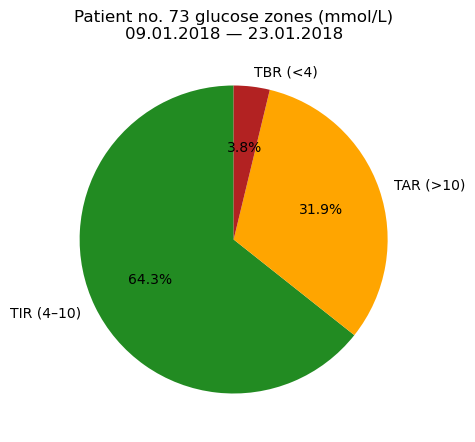

In [147]:
# Proportions of:
# TBR - Time Below Range (< 4 mmol/L)
# TIR - Time in Range (4...10 mmol/L)
# TAR - Time Above Range (> 10 mmol/L)
# in specific date range on specific patient
pt = 73
start_date = '2018-01-09'
end_date = '2018-01-23'

subset = dclp3[
    (dclp3['PtID'] == pt) &
    (dclp3['date'] >= pd.to_datetime(start_date)) &
    (dclp3['date'] <= pd.to_datetime(end_date))
].copy()

if subset.empty:
    print(f"Patient no. {pt} has no data between {start_date} — {end_date}.")
else:
    # Mark the zones; TIR, TAR, and TBR
    subset['zone'] = np.select(
        [subset['CGM_mmol'] < 4,
         subset['CGM_mmol'].between(4, 10),
         subset['CGM_mmol'] > 10],
        ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
        default='missing'
    )

    counts = subset['zone'].value_counts(normalize=True) * 100

    start_date = pd.to_datetime(start_date).strftime("%d.%m.%Y")
    end_date = pd.to_datetime(end_date).strftime("%d.%m.%Y")
    
    if start_date == end_date:
        date_text = f"{start_date}"
    else:
        date_text = f"{start_date} — {end_date}"

    plt.figure(figsize=(5,5))
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['forestgreen','orange','firebrick','gray'], startangle=90)
    plt.title(f'Patient no. {pt} glucose zones (mmol/L)\n{date_text}')
    plt.show()

Same information from the pie chart, but now as lines.

**NB!** The following graph has also been implemented into the large summary graph below (three lines for each patient in that date range).

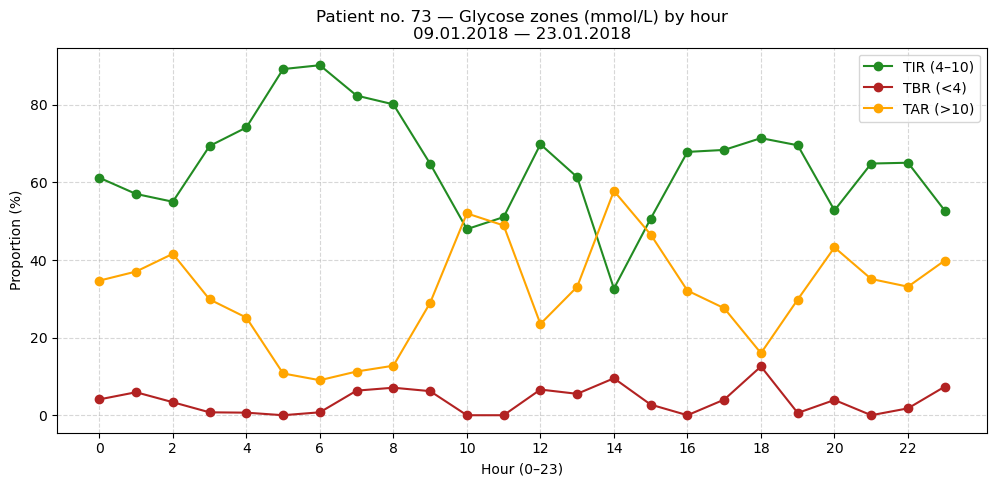

In [148]:
# Proportions of:
# TBR - Time Below Range (< 4 mmol/L)
# TIR - Time in Range (4...10 mmol/L)
# TAR - Time Above Range (> 10 mmol/L)
# in specific date range on specific patient

pt = 73
start_date = '2018-01-09'
end_date = '2018-01-23'

subset = dclp3[
    (dclp3['PtID'] == pt) &
    (dclp3['date'] >= pd.to_datetime(start_date)) &
    (dclp3['date'] <= pd.to_datetime(end_date))
].copy()

if subset.empty:
    print(f"Patient no. {pt} has no data between {start_date} — {end_date}.")
else:
    subset['zone'] = np.select(
        [subset['CGM_mmol'] < 4,
         subset['CGM_mmol'].between(4, 10),
         subset['CGM_mmol'] > 10],
        ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
        default='missing'
    )

    # Summary by hour
    hourly_summary = (
        subset.groupby('hour')['zone']
        .value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    )
    
    # Check that all hours from 0 to 23 exist
    for h in range(24):
        if h not in hourly_summary.index:
            hourly_summary.loc[h] = [0,0,0]  # TBR, TIR, TAR
    hourly_summary = hourly_summary.sort_index()

    # Format date appearance
    start_date = pd.to_datetime(start_date).strftime("%d.%m.%Y")
    end_date = pd.to_datetime(end_date).strftime("%d.%m.%Y")

    if start_date == end_date:
        date_text = f"{start_date}"
    else:
        date_text = f"{start_date} — {end_date}"

    # Plotting
    plt.figure(figsize=(12,5))
    plt.plot(hourly_summary.index, hourly_summary.get('TIR (4–10)', 0), marker='o', color='forestgreen', label='TIR (4–10)')
    plt.plot(hourly_summary.index, hourly_summary.get('TBR (<4)', 0), marker='o', color='firebrick', label='TBR (<4)')
    plt.plot(hourly_summary.index, hourly_summary.get('TAR (>10)', 0), marker='o', color='orange', label='TAR (>10)')
    
    plt.xticks(range(0,24,2))
    plt.xlabel('Hour (0–23)')
    plt.ylabel('Proportion (%)')
    plt.title(f'Patient no. {pt} — Glycose zones (mmol/L) by hour\n{date_text}')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

A patient's complete medical history -- pie chart.

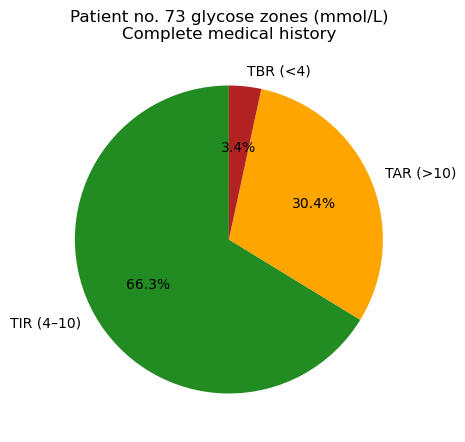

In [149]:
# Proportions of:
# TBR - Time Below Range (< 4 mmol/L)
# TIR - Time in Range (4...10 mmol/L)
# TAR - Time Above Range (> 10 mmol/L)
# Complete medical history

pt = 73

subset = dclp3[dclp3['PtID'] == pt].copy()

subset['zone'] = np.select(
    [subset['CGM_mmol'] < 4,
     subset['CGM_mmol'].between(4, 10),
     subset['CGM_mmol'] > 10],
    ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
    default='missing'
).astype(object)

counts = subset['zone'].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=["forestgreen",'orange', 'firebrick', 'gray'], startangle=90)
plt.title(f'Patient no. {pt} glycose zones (mmol/L)\nComplete medical history')
plt.show()

A patient's complete medical history -- line chart.

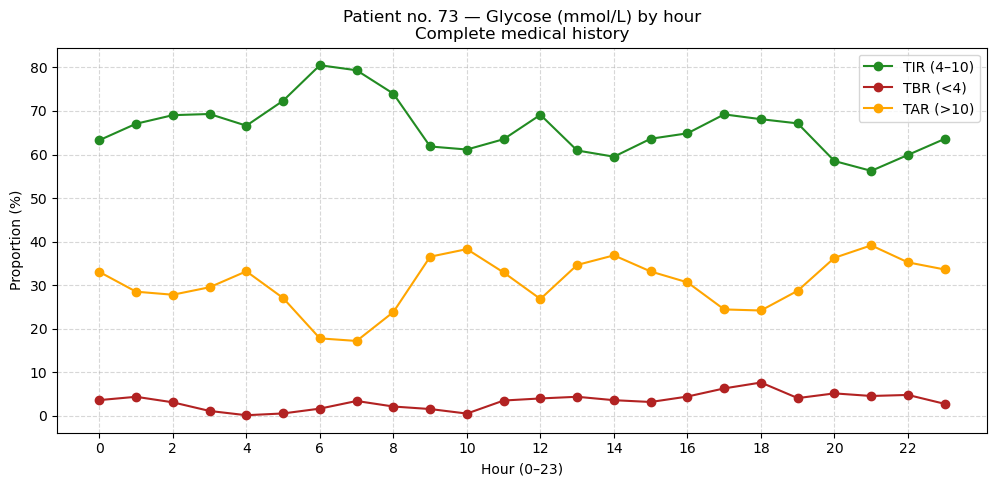

In [150]:
pt = 73

subset = dclp3[dclp3['PtID'] == pt].copy()

if subset.empty:
    print(f"Patient no. {pt} has no data.")
else:
    subset['hour'] = subset['DataDtTm'].dt.hour

    subset['zone'] = np.select(
        [subset['CGM_mmol'] < 4,
         subset['CGM_mmol'].between(4, 10),
         subset['CGM_mmol'] > 10],
        ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
        default='missing'
    )

    hourly_summary = (
        subset.groupby('hour')['zone']
        .value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    )
    
    for h in range(24):
        if h not in hourly_summary.index:
            hourly_summary.loc[h] = [0,0,0]
    hourly_summary = hourly_summary.sort_index()

    plt.figure(figsize=(12,5))
    plt.plot(hourly_summary.index, hourly_summary.get('TIR (4–10)', 0), marker='o', color='forestgreen', label='TIR (4–10)')
    plt.plot(hourly_summary.index, hourly_summary.get('TBR (<4)', 0), marker='o', color='firebrick', label='TBR (<4)')
    plt.plot(hourly_summary.index, hourly_summary.get('TAR (>10)', 0), marker='o', color='orange', label='TAR (>10)')
    
    plt.xticks(range(0,24,2))
    plt.xlabel('Hour (0–23)')
    plt.ylabel('Proportion (%)')
    plt.title(f'Patient no. {pt} — Glycose (mmol/L) by hour\nComplete medical history')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

In [151]:
daily = dclp3.groupby(['PtID', 'date'])['CGM_mmol'].agg(['mean', 'std', 'min', 'max'])

Consecutive patients over a specific date range, showing glucose level fluctuations across the entire time axis (vertical dark dash indicates date change); TIR, TAR and TBR proportions as a line graph, and more specifically the TBR line graph.

NB! Nocturnal hypoglycemia (00-06) and dawn phenomena (04-06) are also shown!

In [152]:
overview[overview['PtID'] == 73]

,PtID,start_date,end_date,period_days
70,73,2018-01-09,2018-07-21,193


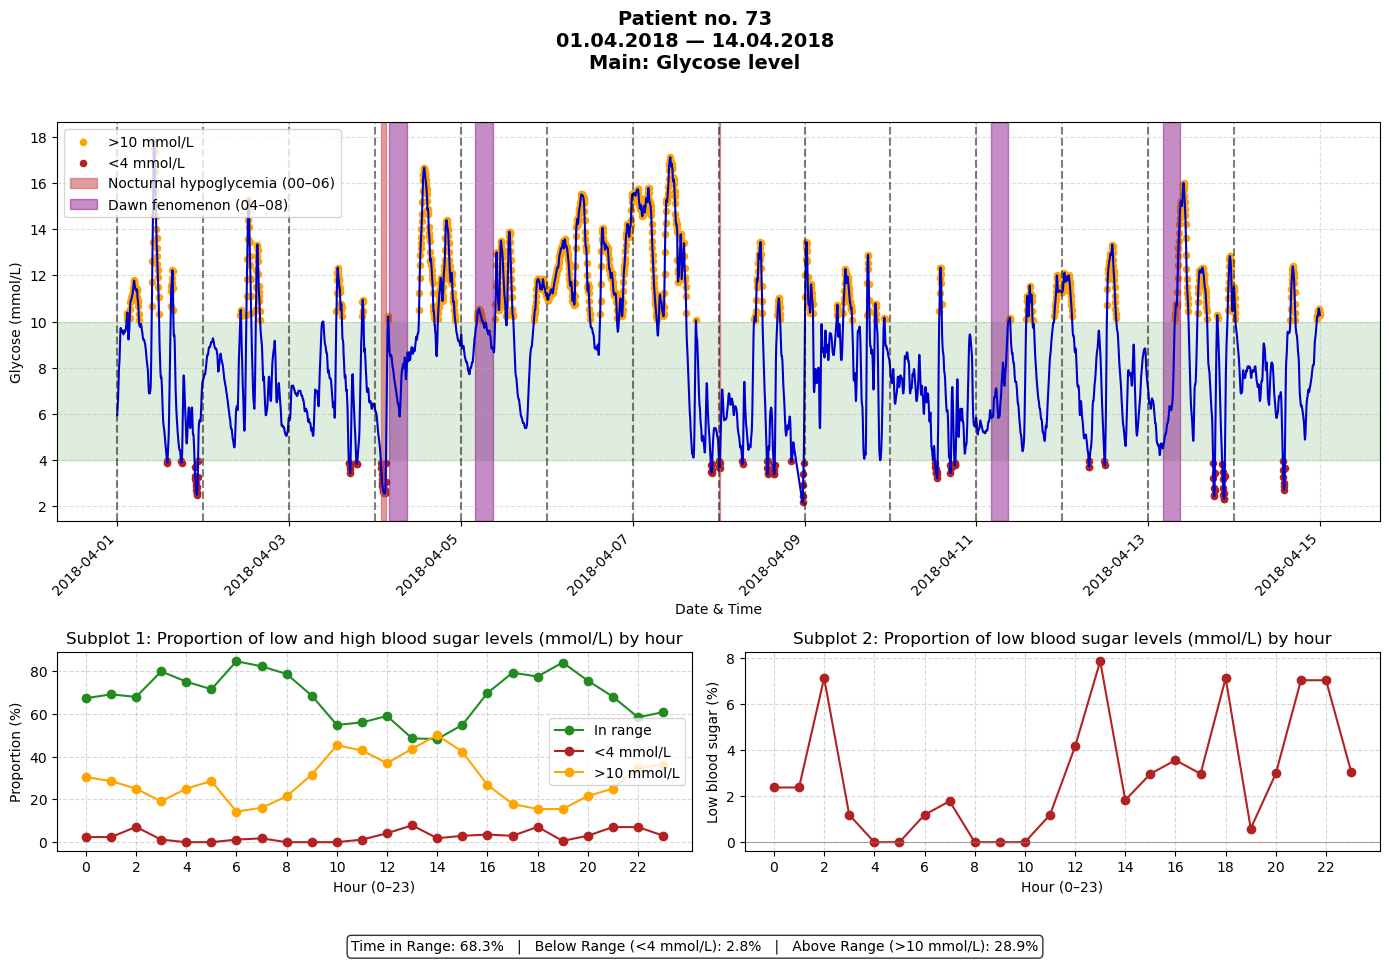

In [153]:
# For a range of patients
dclp3['date'] = pd.to_datetime(dclp3['date'])

start_date = '2018-04-01'
end_date = '2018-04-14'

start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

for pt in range(73, 74):
    subset = dclp3[
        (dclp3['PtID'] == pt) &
        (dclp3['date'] >= start_date) &
        (dclp3['date'] <= end_date)
    ].copy()

    if subset.empty:
        print(f"Patient no. {pt} has no data between {start_date:%d.%m.%Y} -- {end_date:%d.%m.%Y}.")
        continue

    subset['hour'] = subset['DataDtTm'].dt.hour

    subset['zone'] = np.select(
        [subset['CGM_mmol'] < 4,
         subset['CGM_mmol'].between(4, 10),
         subset['CGM_mmol'] > 10],
        ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
        default='missing'
    )

    TIR = (subset['CGM_mmol'].between(4,10)).mean() * 100
    TBR = (subset['CGM_mmol'] < 4).mean() * 100
    TAR = (subset['CGM_mmol'] > 10).mean() * 100

    # Summary by hour
    hourly_summary = (
        subset.groupby('hour')['zone']
        .value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    )

    for h in range(24):
        if h not in hourly_summary.index:
            hourly_summary.loc[h] = [0,0,0]
    hourly_summary = hourly_summary.sort_index()

    start_date_str = start_date.strftime("%d.%m.%Y")
    end_date_str = end_date.strftime("%d.%m.%Y")
    date_text = start_date_str if start_date_str == end_date_str else f"{start_date_str} — {end_date_str}"

    #### Plotting
    fig = plt.figure(figsize=(14,10))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

    ax1 = fig.add_subplot(gs[0, :])
    fig.suptitle(f'Patient no. {pt}\n{date_text}\nMain: Glycose level',
                 fontsize=14, fontweight='bold', y=0.95)

    # Main plot: trends of glycose over time
    ax1.axhspan(4, 10, color='forestgreen', alpha=0.15)
    ax1.plot(subset['DataDtTm'], subset['CGM_mmol'], color='mediumblue')
    ax1.scatter(subset['DataDtTm'][subset['CGM_mmol'] > 10], subset['CGM_mmol'][subset['CGM_mmol'] > 10],
                color='orange', s=20, label='>10 mmol/L')
    ax1.scatter(subset['DataDtTm'][subset['CGM_mmol'] < 4], subset['CGM_mmol'][subset['CGM_mmol'] < 4],
                color='firebrick', s=20, label='<4 mmol/L')

    # nocturnal hypoglycemia (00–06)
    night_hours = range(0,6)
    night_label_added = False
    
    for d in subset['date'].sort_values().unique():
        day_mask = subset['date'] == d
        night_mask = day_mask & subset['hour'].isin(night_hours) & (subset['CGM_mmol'] < 4)
        
        if night_mask.any():
            start_time = subset.loc[night_mask, 'DataDtTm'].min()
            end_time   = subset.loc[night_mask, 'DataDtTm'].max()
            label = "Nocturnal hypoglycemia (00–06)" if not night_label_added else None
            ax1.axvspan(start_time, end_time, color='indianred', alpha=0.6, label=label)
            night_label_added = True

    # dawn fenomenon (04–08)
    dawn_hours = range(4,9)
    dawn_label_added = False
    
    for d in subset['date'].sort_values().unique():
        day_mask = subset['date'] == d
        before_mask = day_mask & subset['hour'].isin(range(0,4))
        after_mask  = day_mask & subset['hour'].isin(dawn_hours)
    
        if before_mask.any() and after_mask.any():
            mean_before = subset.loc[before_mask, 'CGM_mmol'].mean()
            mean_after  = subset.loc[after_mask, 'CGM_mmol'].mean()
    
            if mean_after - mean_before > 1.1:  # tõus > 1.1 mmol/L
                start_time = subset.loc[after_mask, 'DataDtTm'].min()
                end_time   = subset.loc[after_mask, 'DataDtTm'].max()
                label = "Dawn fenomenon (04–08)" if not dawn_label_added else None
                ax1.axvspan(start_time, end_time, color='purple', alpha=0.45, label=label)
                dawn_label_added = True

    # Separate date change
    for d in subset['date'].sort_values().unique():
        dt_start = pd.to_datetime(d)
        ax1.axvline(dt_start, color='black', linestyle='--', alpha=0.5)
    
    ax1.set_xlabel('Date & Time')
    ax1.set_ylabel('Glycose (mmol/L)')
    ax1.grid(True, linestyle='--', alpha=0.4)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.legend(loc='upper left')

    # Subplot 1: proportions
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(hourly_summary.index, hourly_summary.get('TIR (4–10)', 0), marker='o', color='forestgreen', label='In range')
    ax2.plot(hourly_summary.index, hourly_summary.get('TBR (<4)', 0), marker='o', color='firebrick', label='<4 mmol/L')
    ax2.plot(hourly_summary.index, hourly_summary.get('TAR (>10)', 0), marker='o', color='orange', label='>10 mmol/L')
    ax2.set_title('Subplot 1: Proportion of low and high blood sugar levels (mmol/L) by hour')
    ax2.set_xlabel('Hour (0–23)')
    ax2.set_ylabel('Proportion (%)')
    ax2.set_xticks(range(0,24,2))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    # Subplot 2: low glucose details
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(hourly_summary.index, hourly_summary.get('TBR (<4)', 0), marker='o', color='firebrick', label='<4 mmol/L')
    ax3.axhline(0, color='gray', linewidth=0.5)
    ax3.set_title('Subplot 2: Proportion of low blood sugar levels (mmol/L) by hour')
    ax3.set_xlabel('Hour (0–23)')
    ax3.set_ylabel('Low blood sugar (%)')
    ax3.set_xticks(range(0,24,2))
    ax3.grid(True, linestyle='--', alpha=0.5)

    # Info text
    fig.text(0.5, 0.02,
             f"Time in Range: {TIR:.1f}%   |   Below Range (<4 mmol/L): {TBR:.1f}%   |   Above Range (>10 mmol/L): {TAR:.1f}%",
             ha='center', va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout(rect=[0, 0.05, 1, 0.93])

    fname = f"patient_glycose_trends.png"

    fig.savefig(
        fname,
        dpi=500,            
        bbox_inches="tight", 
        facecolor="white"
    )
    plt.show()

Instead of a time axis of glucose levels, the x-axis now has hours (0-23) and then AVERAGED glucose levels per hour. Figures 2 and 3 are the same as before. Basically more detailed breakdown of Figure 1.

In [154]:
overview[overview['PtID'] == 73]

,PtID,start_date,end_date,period_days
70,73,2018-01-09,2018-07-21,193


In [155]:
overview[overview['PtID'].isin([73])]

,PtID,start_date,end_date,period_days
70,73,2018-01-09,2018-07-21,193


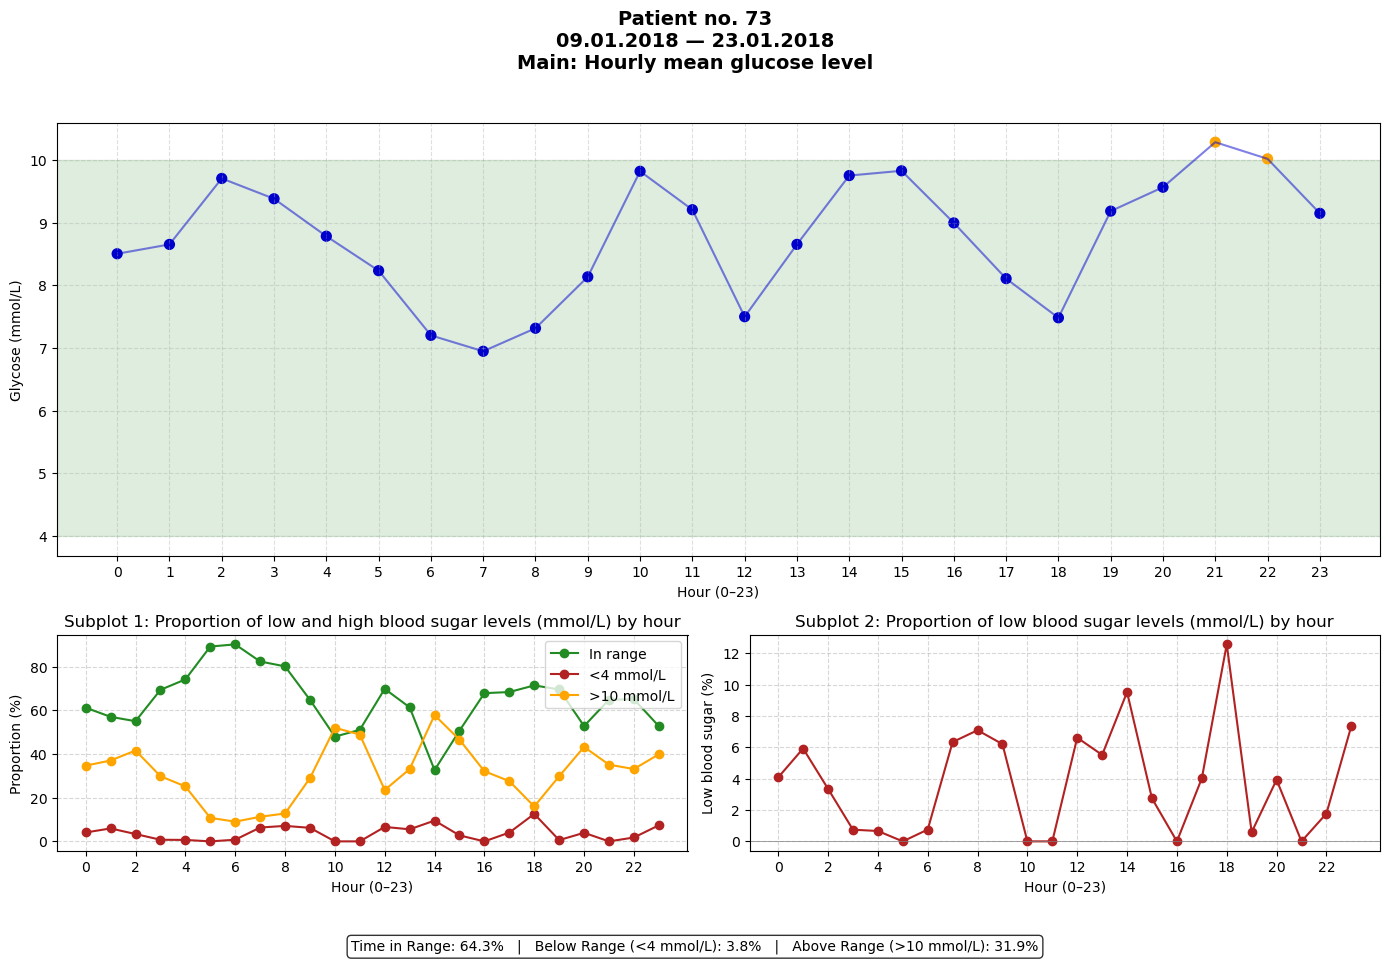

In [156]:
# For a range of patients
start_date = '2018-01-09'
end_date = '2018-01-23'

start_date = pd.to_datetime(start_date)
end_date = pd.to_datetime(end_date)

for pt in range(73, 74):
    subset = dclp3[
        (dclp3['PtID'] == pt) &
        (dclp3['date'] >= start_date) &
        (dclp3['date'] <= end_date)
    ].copy()

    if subset.empty:
        print(f"Patient no. {pt} has no data between {start_date:%d.%m.%Y} — {end_date:%d.%m.%Y}.")
        continue

    subset['hour'] = subset['DataDtTm'].dt.hour

    subset['zone'] = np.select(
        [subset['CGM_mmol'] < 4,
         subset['CGM_mmol'].between(4, 10),
         subset['CGM_mmol'] > 10],
        ['TBR (<4)', 'TIR (4–10)', 'TAR (>10)'],
        default='missing'
    )

    TIR = (subset['CGM_mmol'].between(4,10)).mean() * 100
    TBR = (subset['CGM_mmol'] < 4).mean() * 100
    TAR = (subset['CGM_mmol'] > 10).mean() * 100

    # Summary by hour
    hourly_summary = (
        subset.groupby('hour')['zone']
        .value_counts(normalize=True)
        .unstack(fill_value=0) * 100
    )

    # Check that all hours from 0 to 23 exist
    for h in range(24):
        if h not in hourly_summary.index:
            hourly_summary.loc[h] = [0,0,0]
    hourly_summary = hourly_summary.sort_index()

    # Aggregate mean glucose per hour for main plot
    hourly_mean = subset.groupby('hour')['CGM_mmol'].mean()

    # Determine colors based on mean glucose
    colors = ['firebrick' if val < 4 else 'orange' if val > 10 else 'mediumblue'
              for val in hourly_mean.values]

    # Format date appearance
    start_date_str = start_date.strftime("%d.%m.%Y")
    end_date_str = end_date.strftime("%d.%m.%Y")
    
    if start_date_str == end_date_str:
        date_text = f"{start_date_str}"
    else:
        date_text = f"{start_date_str} — {end_date_str}"

    fig = plt.figure(figsize=(14,10))
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1])

    ax1 = fig.add_subplot(gs[0, :])
    fig.suptitle(f'Patient no. {pt}\n{date_text}\nMain: Hourly mean glucose level',
                 fontsize=14, fontweight='bold', y=0.95)

    # Main plot: trends of glycose over time (mean per hour)
    ax1.axhspan(4, 10, color='forestgreen', alpha=0.15)
    ax1.scatter(hourly_mean.index, hourly_mean.values, color=colors, s=50)
    ax1.plot(hourly_mean.index, hourly_mean.values, color='mediumblue', alpha=0.5)

    # --- Nocturnal hypoglycemia (00–06) ja dawn fenomenon (04–08) based hourly_mean ---
    night_hours = range(0,6)
    dawn_hours = range(4,9)
    
    night_label_added = False
    dawn_label_added  = False
    
    # Loop for each date (hourly_mean is not date-specific, so the entire sample is used for one plot)
    # Nocturnal hypoglycemia: mean < 4 mmol/L tunnis 0–5
    if (hourly_mean.loc[hourly_mean.index.isin(night_hours)] < 4).any():
        mask = hourly_mean.index.isin(night_hours) & (hourly_mean < 4)
        if mask.any():
            start_hour = mask.idxmax()          # the first hour that meets the condition
            end_hour   = mask[::-1].idxmax()    # last hour
            label = "Nocturnal hypoglycemia (00–06)" if not night_label_added else None
            ax1.axvspan(start_hour, end_hour, color='indianred', alpha=0.6, label=label)
            night_label_added = True
    
    # Dawn fenomenon: rise >1.1 mmol/L 04–08 vs 00–03
    mean_before = hourly_mean.loc[hourly_mean.index.isin(range(0,4))].mean()
    mean_after  = hourly_mean.loc[hourly_mean.index.isin(dawn_hours)].mean()
    
    if mean_after - mean_before > 1.1:
        start_hour = dawn_hours.start
        end_hour   = dawn_hours.stop - 1
        label = "Dawn fenomenon (04–08)" if not dawn_label_added else None
        ax1.axvspan(start_hour, end_hour, color='purple', alpha=0.45, label=label)
        dawn_label_added = True
    
    handles, labels = ax1.get_legend_handles_labels()
    if handles:
        ax1.legend()


    
    ax1.set_xlabel('Hour (0–23)')
    ax1.set_ylabel('Glycose (mmol/L)')
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.set_xticks(range(0,24,1))

    # Subplot 1:  proportions of low and high blood sugar levels
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(hourly_summary.index, hourly_summary.get('TIR (4–10)', 0), marker='o', color='forestgreen', label='In range')
    ax2.plot(hourly_summary.index, hourly_summary.get('TBR (<4)', 0), marker='o', color='firebrick', label='<4 mmol/L')
    ax2.plot(hourly_summary.index, hourly_summary.get('TAR (>10)', 0), marker='o', color='orange', label='>10 mmol/L')
    ax2.set_title('Subplot 1: Proportion of low and high blood sugar levels (mmol/L) by hour')
    ax2.set_xlabel('Hour (0–23)')
    ax2.set_ylabel('Proportion (%)')
    ax2.set_xticks(range(0,24,2))
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    # Subplot 2
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(hourly_summary.index, hourly_summary.get('TBR (<4)', 0), marker='o', color='firebrick', label='<4 mmol/L')
    ax3.axhline(0, color='gray', linewidth=0.5)
    ax3.set_title('Subplot 2: Proportion of low blood sugar levels (mmol/L) by hour')
    ax3.set_xlabel('Hour (0–23)')
    ax3.set_ylabel('Low blood sugar (%)')
    ax3.set_xticks(range(0,24,2))
    ax3.grid(True, linestyle='--', alpha=0.5)

    # Informational text
    fig.text(0.5, 0.02,
             f"Time in Range: {TIR:.1f}%   |   Below Range (<4 mmol/L): {TBR:.1f}%   |   Above Range (>10 mmol/L): {TAR:.1f}%",
             ha='center', va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout(rect=[0, 0.05, 1, 0.93])
    plt.show()